In [17]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.feature import hog, local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from scipy.stats import kstest, ttest_ind, mannwhitneyu

# Load preprocessed Images

In [3]:
def load_image_paths(directory):
    return [os.path.join(directory, f) for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

normal_processed_dir = r'../data/processed/normal'
pneumonia_processed_dir = r'../data/processed/pneumonia'

normal_clahe_paths = load_image_paths(normal_processed_dir)
pneumonia_clahe_paths = load_image_paths(pneumonia_processed_dir)

print(f'Loaded {len(normal_clahe_paths)} normal images and {len(pneumonia_clahe_paths)} pneumonia images.')

Loaded 250 normal images and 250 pneumonia images.


# HOG and LBP Feature Extraction (Many LBP Features)

In [18]:
def extract_hog_features(image_paths, pixels_per_cell=(4, 4), cells_per_block=(2, 2), visualize=False):
    features = []
    for path in image_paths:
        img = np.array(Image.open(path).convert('L')) / 255.0
        hog_feat = hog(
            img,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            visualize=False,
            feature_vector=True
        )
        features.append(hog_feat)
    return np.array(features)

def extract_lbp_features_many(image_paths, P=24, R_list=None, method='uniform'):
    if R_list is None:
        R_list = list(range(1, 31))  # 30 radii for many features
    features = []
    for path in image_paths:
        img = np.array(Image.open(path).convert('L')) / 255.0
        img_features = []
        for R in R_list:
            lbp = local_binary_pattern(img, P, R, method=method)
            hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, P + 3), range=(0, P + 2))
            hist = hist.astype('float')
            hist /= (hist.sum() + 1e-6)
            img_features.extend(hist)
        features.append(img_features)
    return np.array(features)

# Extract features
normal_hog = extract_hog_features(normal_clahe_paths)
pneumonia_hog = extract_hog_features(pneumonia_clahe_paths)
normal_lbp = extract_lbp_features_many(normal_clahe_paths)
pneumonia_lbp = extract_lbp_features_many(pneumonia_clahe_paths)

print('HOG normal shape:', normal_hog.shape)
print('HOG pneumonia shape:', pneumonia_hog.shape)
print('LBP normal shape:', normal_lbp.shape)
print('LBP pneumonia shape:', pneumonia_lbp.shape)

c:\Users\User\Documents\UdeA\Señales II\Proyecto Final\Pneumonia-Detection\.venv\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


HOG normal shape: (250, 34596)
HOG pneumonia shape: (250, 34596)
LBP normal shape: (250, 780)
LBP pneumonia shape: (250, 780)


# Unify all features in a DataFrame

In [19]:
X_normal = np.hstack([normal_hog, normal_lbp])
X_pneumonia = np.hstack([pneumonia_hog, pneumonia_lbp])
y_normal = np.zeros(X_normal.shape[0], dtype=int)
y_pneumonia = np.ones(X_pneumonia.shape[0], dtype=int)
X = np.vstack([X_normal, X_pneumonia])
y = np.concatenate([y_normal, y_pneumonia])
df = pd.DataFrame(X)
df['label'] = y
print(df.shape)
df.head()

(500, 35377)


,0,1,2,3,4,5,6,7,8,9,...,35367,35368,35369,35370,35371,35372,35373,35374,35375,label
0,0.304963,0.00000,0.0,0.0,0.068710,0.000000,0.213733,0.184476,0.304963,0.304963,...,0.001709,0.000610,0.001282,0.000427,0.003174,0.003845,0.017700,0.018494,0.722107,0
1,0.349867,0.06406,0.0,0.0,0.039186,0.000000,0.000000,0.000000,0.148155,0.349867,...,0.002136,0.002502,0.004517,0.001648,0.002136,0.002930,0.010681,0.015137,0.690979,0
2,0.271176,0.00000,0.0,0.0,0.013559,0.011181,0.000000,0.365818,0.256427,0.365818,...,0.004639,0.001770,0.003967,0.001404,0.001587,0.003845,0.009705,0.016663,0.671204,0
3,0.210184,0.00000,0.0,0.0,0.105092,0.000000,0.000000,0.319426,0.255849,0.243213,...,0.000610,0.000061,0.003540,0.000305,0.003540,0.003784,0.016174,0.015991,0.744873,0
4,0.183156,0.00000,0.0,0.0,0.226238,0.309743,0.309743,0.270943,0.079837,0.078495,...,0.003784,0.001587,0.002747,0.003601,0.003540,0.002869,0.009460,0.013550,0.663696,0


# Standardize features

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('label', axis=1))
df_scaled = pd.DataFrame(X_scaled, columns=df.columns[:-1])
df_scaled['label'] = df['label'].values

# Statistical tests and feature selection

In [ ]:
X_normal = df[df['label'] == 0].drop('label', axis=1).values
X_pneumonia = df[df['label'] == 1].drop('label', axis=1).values
normality_results = []
stat_test_results = []
for i in range(X_normal.shape[1]):
    stat_norm, p_norm = kstest(X_normal[:, i], 'norm')
    stat_pneu, p_pneu = kstest(X_pneumonia[:, i], 'norm')
    is_normal = (p_norm > 0.05) and (p_pneu > 0.05)
    normality_results.append(is_normal)
    if is_normal:
        stat, p = ttest_ind(X_normal[:, i], X_pneumonia[:, i], equal_var=False)
        test_used = 't-test'
    else:
        stat, p = mannwhitneyu(X_normal[:, i], X_pneumonia[:, i], alternative='two-sided')
        test_used = 'mannwhitneyu'
    stat_test_results.append({'feature': i, 'test': test_used, 'p_value': p})
n_normal = sum(normality_results)
print(f'Features normally distributed in both classes: {n_normal} of {len(normality_results)}')
same_dist_count = sum(res['p_value'] > 0.05 for res in stat_test_results)
print(f'Features with no significant difference between classes (p > 0.05): {same_dist_count} of {len(stat_test_results)}')

# Dimensionality reduction and visualization

PCA reduced shape (95% variance): (500, 447)


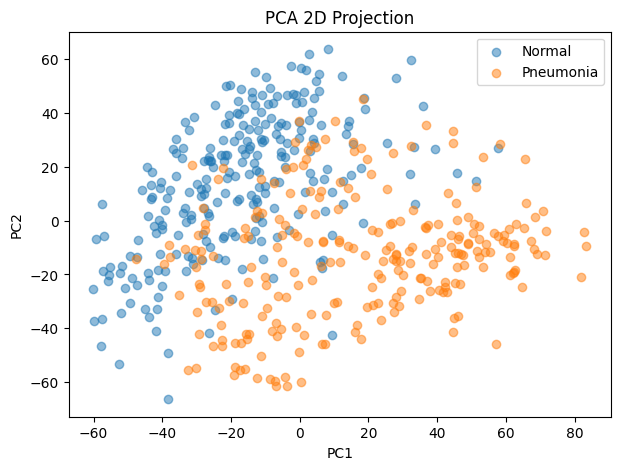

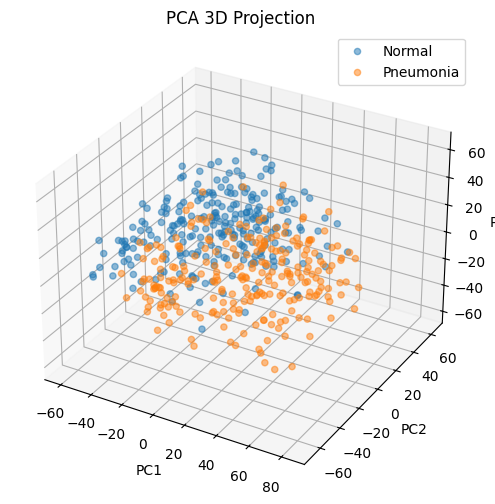

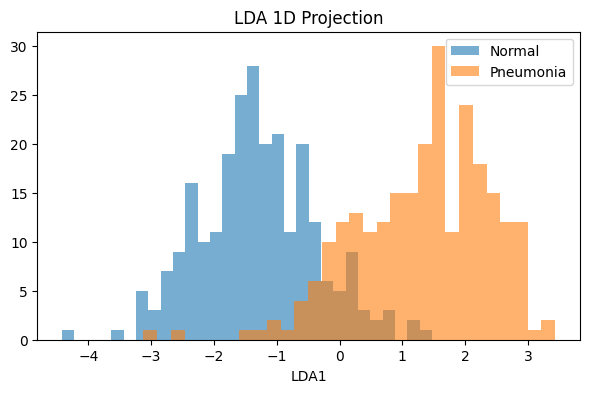

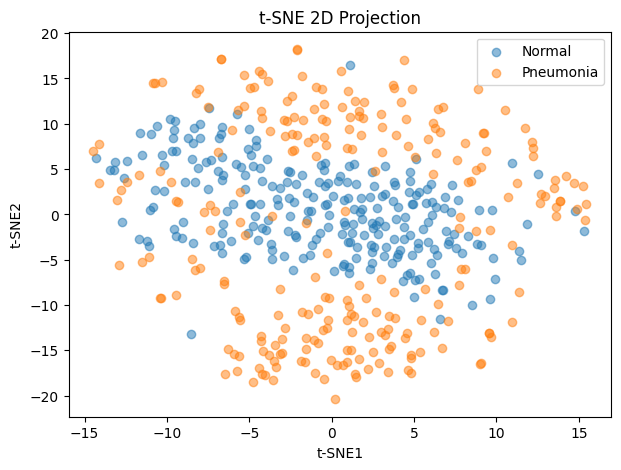

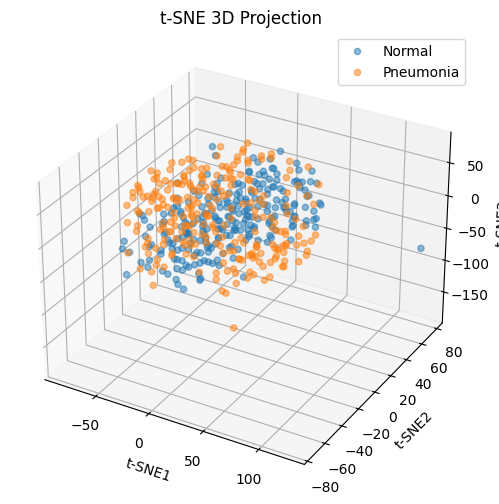

In [8]:
X_features = df_scaled.drop('label', axis=1).values
y_labels = df_scaled['label'].values
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_features)
print(f'PCA reduced shape (95% variance): {X_pca.shape}')
plt.figure(figsize=(7,5))
plt.scatter(X_pca[y_labels==0, 0], X_pca[y_labels==0, 1], alpha=0.5, label='Normal')
plt.scatter(X_pca[y_labels==1, 0], X_pca[y_labels==1, 1], alpha=0.5, label='Pneumonia')
plt.title('PCA 2D Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[y_labels==0, 0], X_pca[y_labels==0, 1], X_pca[y_labels==0, 2], alpha=0.5, label='Normal')
ax.scatter(X_pca[y_labels==1, 0], X_pca[y_labels==1, 1], X_pca[y_labels==1, 2], alpha=0.5, label='Pneumonia')
ax.set_title('PCA 3D Projection')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.show()
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_features, y_labels)
plt.figure(figsize=(7,4))
plt.hist(X_lda[y_labels==0], bins=30, alpha=0.6, label='Normal')
plt.hist(X_lda[y_labels==1], bins=30, alpha=0.6, label='Pneumonia')
plt.title('LDA 1D Projection')
plt.xlabel('LDA1')
plt.legend()
plt.show()
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_2d = tsne_2d.fit_transform(X_features)
plt.figure(figsize=(7,5))
plt.scatter(X_tsne_2d[y_labels==0, 0], X_tsne_2d[y_labels==0, 1], alpha=0.5, label='Normal')
plt.scatter(X_tsne_2d[y_labels==1, 0], X_tsne_2d[y_labels==1, 1], alpha=0.5, label='Pneumonia')
plt.title('t-SNE 2D Projection')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.legend()
plt.show()
tsne_3d = TSNE(n_components=3, random_state=42, perplexity=30)
X_tsne_3d = tsne_3d.fit_transform(X_features)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_tsne_3d[y_labels==0, 0], X_tsne_3d[y_labels==0, 1], X_tsne_3d[y_labels==0, 2], alpha=0.5, label='Normal')
ax.scatter(X_tsne_3d[y_labels==1, 0], X_tsne_3d[y_labels==1, 1], X_tsne_3d[y_labels==1, 2], alpha=0.5, label='Pneumonia')
ax.set_title('t-SNE 3D Projection')
ax.set_xlabel('t-SNE1')
ax.set_ylabel('t-SNE2')
ax.set_zlabel('t-SNE3')
ax.legend()
plt.show()

# Test a Hypothesis about only HOG or only LBP features

Visualización SOLO HOG


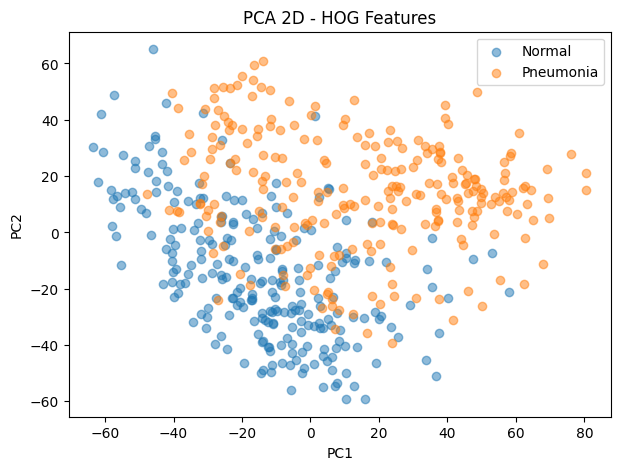

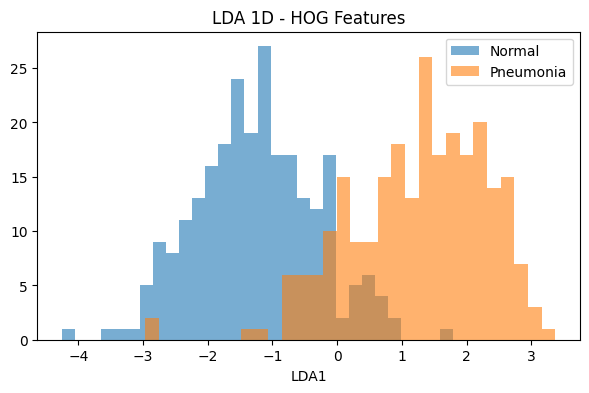

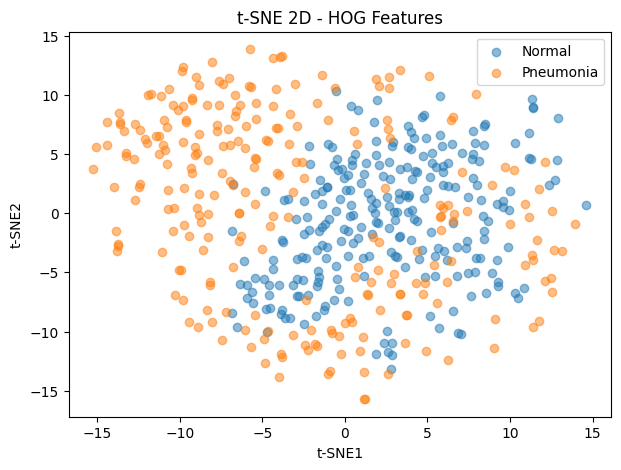

Visualización SOLO LBP


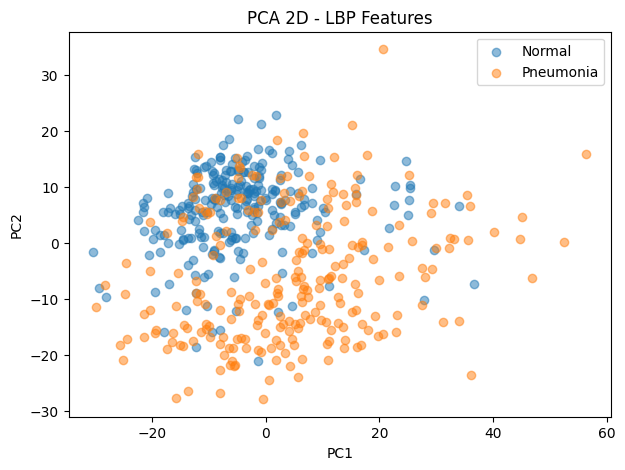

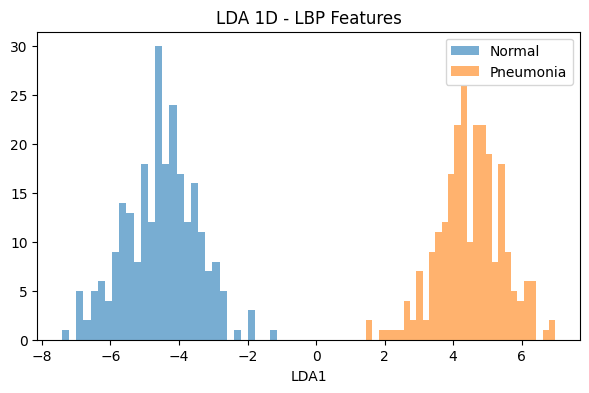

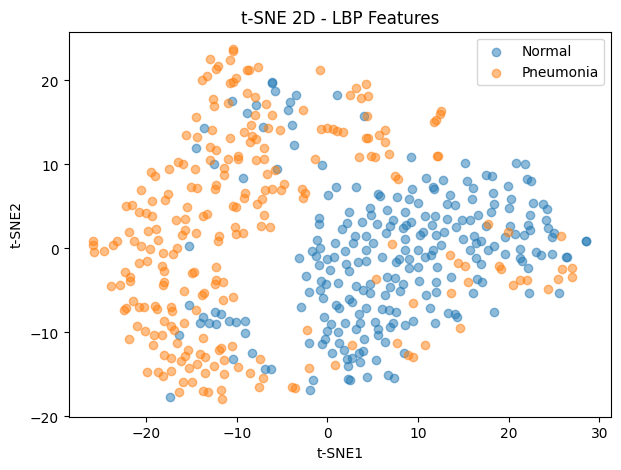

In [9]:
hog_cols = range(normal_hog.shape[1]) 
X_hog = df_scaled.iloc[:, list(hog_cols)].values

lbp_start = normal_hog.shape[1]
lbp_end = lbp_start + normal_lbp.shape[1]
lbp_cols = range(lbp_start, lbp_end)
X_lbp = df_scaled.iloc[:, list(lbp_cols)].values

y_labels = df_scaled['label'].values

print("Visualización SOLO HOG")
pca_hog = PCA(n_components=2, random_state=42)
X_pca_hog = pca_hog.fit_transform(X_hog)
plt.figure(figsize=(7,5))
plt.scatter(X_pca_hog[y_labels==0, 0], X_pca_hog[y_labels==0, 1], alpha=0.5, label='Normal')
plt.scatter(X_pca_hog[y_labels==1, 0], X_pca_hog[y_labels==1, 1], alpha=0.5, label='Pneumonia')
plt.title('PCA 2D - HOG Features')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

lda_hog = LDA(n_components=1)
X_lda_hog = lda_hog.fit_transform(X_hog, y_labels)
plt.figure(figsize=(7,4))
plt.hist(X_lda_hog[y_labels==0], bins=30, alpha=0.6, label='Normal')
plt.hist(X_lda_hog[y_labels==1], bins=30, alpha=0.6, label='Pneumonia')
plt.title('LDA 1D - HOG Features')
plt.xlabel('LDA1')
plt.legend()
plt.show()

tsne_hog = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_hog = tsne_hog.fit_transform(X_hog)
plt.figure(figsize=(7,5))
plt.scatter(X_tsne_hog[y_labels==0, 0], X_tsne_hog[y_labels==0, 1], alpha=0.5, label='Normal')
plt.scatter(X_tsne_hog[y_labels==1, 0], X_tsne_hog[y_labels==1, 1], alpha=0.5, label='Pneumonia')
plt.title('t-SNE 2D - HOG Features')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.legend()
plt.show()

print("Visualización SOLO LBP")
pca_lbp = PCA(n_components=2, random_state=42)
X_pca_lbp = pca_lbp.fit_transform(X_lbp)
plt.figure(figsize=(7,5))
plt.scatter(X_pca_lbp[y_labels==0, 0], X_pca_lbp[y_labels==0, 1], alpha=0.5, label='Normal')
plt.scatter(X_pca_lbp[y_labels==1, 0], X_pca_lbp[y_labels==1, 1], alpha=0.5, label='Pneumonia')
plt.title('PCA 2D - LBP Features')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

lda_lbp = LDA(n_components=1)
X_lda_lbp = lda_lbp.fit_transform(X_lbp, y_labels)
plt.figure(figsize=(7,4))
plt.hist(X_lda_lbp[y_labels==0], bins=30, alpha=0.6, label='Normal')
plt.hist(X_lda_lbp[y_labels==1], bins=30, alpha=0.6, label='Pneumonia')
plt.title('LDA 1D - LBP Features')
plt.xlabel('LDA1')
plt.legend()
plt.show()

tsne_lbp = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_lbp = tsne_lbp.fit_transform(X_lbp)
plt.figure(figsize=(7,5))
plt.scatter(X_tsne_lbp[y_labels==0, 0], X_tsne_lbp[y_labels==0, 1], alpha=0.5, label='Normal')
plt.scatter(X_tsne_lbp[y_labels==1, 0], X_tsne_lbp[y_labels==1, 1], alpha=0.5, label='Pneumonia')
plt.title('t-SNE 2D - LBP Features')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.legend()
plt.show()

Initial LBP feature shape: (500, 780)
Initial LBP feature shape: (500, 780)
Features normally distributed in both classes: 50 of 780
Features with no significant difference between classes (p > 0.05): 176 of 780
LBP feature shape after statistical selection: (500, 604)
LBP feature shape after statistical selection: (500, 604)
Features normally distributed in both classes: 50 of 780
Features with no significant difference between classes (p > 0.05): 176 of 780
LBP feature shape after statistical selection: (500, 604)
LBP feature shape after statistical selection: (500, 604)


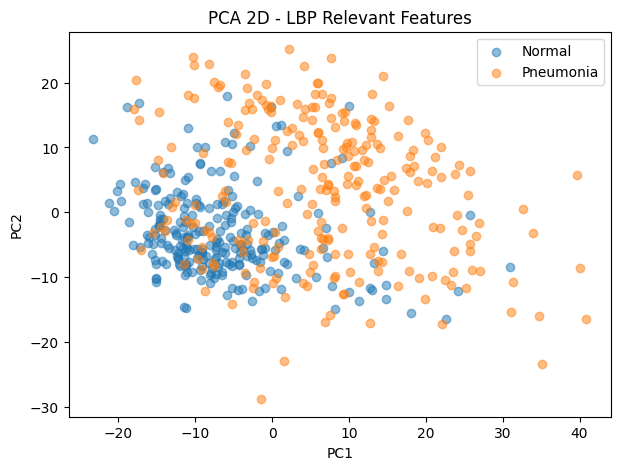

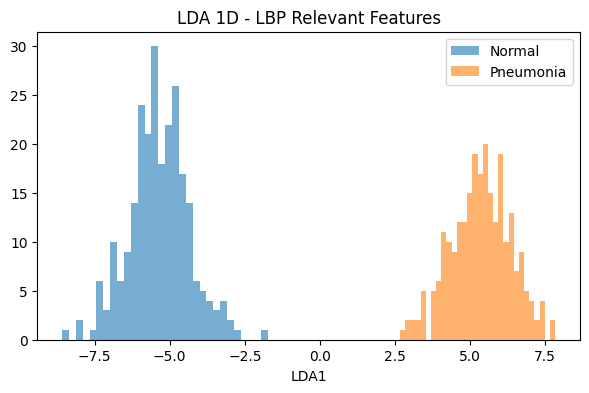

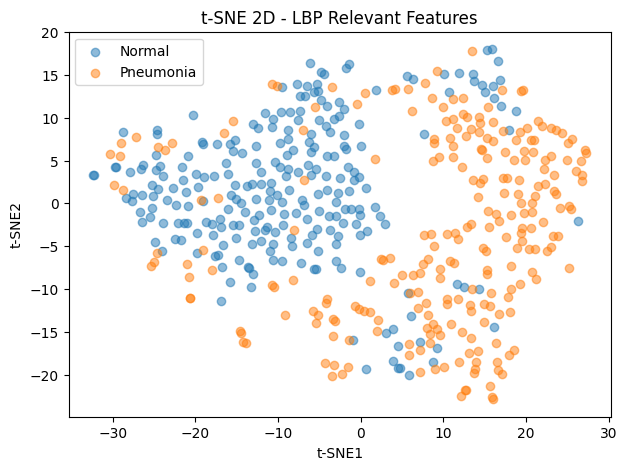

In [21]:
lbp_start = normal_hog.shape[1]
lbp_end = lbp_start + normal_lbp.shape[1]
lbp_cols = df_scaled.columns[:-1][normal_hog.shape[1]:]
X_lbp = df_scaled.loc[:, lbp_cols].values
y_labels = df_scaled['label'].values

print(f"Initial LBP feature shape: {X_lbp.shape}")

print(f"Initial LBP feature shape: {X_lbp.shape}")

X_lbp_normal = X_lbp[y_labels == 0]
X_lbp_pneumonia = X_lbp[y_labels == 1]

normality_results = []
stat_test_results = []
for i in range(X_lbp.shape[1]):
    stat_norm, p_norm = kstest(X_lbp_normal[:, i], 'norm')
    stat_pneu, p_pneu = kstest(X_lbp_pneumonia[:, i], 'norm')
    is_normal = (p_norm > 0.05) and (p_pneu > 0.05)
    normality_results.append(is_normal)
    if is_normal:
        stat, p = ttest_ind(X_lbp_normal[:, i], X_lbp_pneumonia[:, i], equal_var=False)
        test_used = 't-test'
    else:
        stat, p = mannwhitneyu(X_lbp_normal[:, i], X_lbp_pneumonia[:, i], alternative='two-sided')
        test_used = 'mannwhitneyu'
    stat_test_results.append({'feature': i, 'test': test_used, 'p_value': p})

n_normal = sum(normality_results)
print(f'Features normally distributed in both classes: {n_normal} of {len(normality_results)}')
same_dist_count = sum(res['p_value'] > 0.05 for res in stat_test_results)
print(f'Features with no significant difference between classes (p > 0.05): {same_dist_count} of {len(stat_test_results)}')

relevant_features_idx = [i for i, res in enumerate(stat_test_results) if res['p_value'] <= 0.05]
X_lbp_relevant = X_lbp[:, relevant_features_idx]
print(f"LBP feature shape after statistical selection: {X_lbp_relevant.shape}")

print(f"LBP feature shape after statistical selection: {X_lbp_relevant.shape}")

if X_lbp_relevant.shape[1] == 0:
    print("No relevant LBP features found after statistical selection. Adjust your p-value threshold or check your data.")
else:
    pca_lbp = PCA(n_components=2, random_state=42)
    X_pca_lbp = pca_lbp.fit_transform(X_lbp_relevant)
    plt.figure(figsize=(7,5))
    plt.scatter(X_pca_lbp[y_labels==0, 0], X_pca_lbp[y_labels==0, 1], alpha=0.5, label='Normal')
    plt.scatter(X_pca_lbp[y_labels==1, 0], X_pca_lbp[y_labels==1, 1], alpha=0.5, label='Pneumonia')
    plt.title('PCA 2D - LBP Relevant Features')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.show()

    lda_lbp = LDA(n_components=1)
    X_lda_lbp = lda_lbp.fit_transform(X_lbp_relevant, y_labels)
    plt.figure(figsize=(7,4))
    plt.hist(X_lda_lbp[y_labels==0], bins=30, alpha=0.6, label='Normal')
    plt.hist(X_lda_lbp[y_labels==1], bins=30, alpha=0.6, label='Pneumonia')
    plt.title('LDA 1D - LBP Relevant Features')
    plt.xlabel('LDA1')
    plt.legend()
    plt.show()

    tsne_lbp = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne_lbp = tsne_lbp.fit_transform(X_lbp_relevant)
    plt.figure(figsize=(7,5))
    plt.scatter(X_tsne_lbp[y_labels==0, 0], X_tsne_lbp[y_labels==0, 1], alpha=0.5, label='Normal')
    plt.scatter(X_tsne_lbp[y_labels==1, 0], X_tsne_lbp[y_labels==1, 1], alpha=0.5, label='Pneumonia')
    plt.title('t-SNE 2D - LBP Relevant Features')
    plt.xlabel('t-SNE1')
    plt.ylabel('t-SNE2')
    plt.legend()
    plt.show()


# Export LBP Dataset

In [22]:
df_lbp_relevant = pd.DataFrame(X_lbp_relevant)
df_lbp_relevant['label'] = y_labels
df_lbp_relevant.to_csv('../data/processed/lbp_relevant_features.csv', index=False)
print("Exported to ../data/processed/lbp_relevant_features.csv")

Exported to ../data/processed/lbp_relevant_features.csv


# Conclusions

Based on the hypothesis and experimental results, LBP features alone provide superior class separation compared to HOG features for pneumonia detection in chest X-ray images. Visualizations using PCA, LDA, and t-SNE consistently show that LBP features yield clearer boundaries and less overlap between normal and pneumonia cases. Therefore, focusing exclusively on LBP features is the most effective strategy for this classification problem.

## Medical Perspective: Why LBP Is Better
From a medical imaging standpoint, LBP (Local Binary Patterns) excels at capturing fine-grained texture variations in lung tissue. Pneumonia often manifests as changes in texture—such as increased granularity, consolidation, or irregular patterns—rather than just strong edges or gradients. HOG features are designed to capture edge orientation and shape, which may not be as sensitive to these subtle textural changes.

LBP’s ability to quantify local texture makes it particularly suited for identifying pathological changes in chest X-rays, where the presence of pneumonia alters the normal texture of lung parenchyma. By extracting LBP features at multiple scales, the model can detect both small and large textural anomalies, leading to more accurate and robust classification.